# Milestone 1 - Data Exploration

Exploring the **Appliances** category from the Amazon Reviews 2023 dataset.

We use DuckDB to stream the data directly from the McAuley Lab servers and convert to parquet locally.

In [1]:
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
CATEGORY = "Appliances"
BASE_URL = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw"

REVIEWS_URL = f"{BASE_URL}/review_categories/{CATEGORY}.jsonl.gz"
META_URL = f"{BASE_URL}/meta_categories/meta_{CATEGORY}.jsonl.gz"

DATA_DIR = Path("..") / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
con = duckdb.connect()

## Preview raw data

Peek at first few rows directly from the remote files before downloading anything large.

In [4]:
head_reviews = con.execute(f"SELECT * FROM read_json_auto('{REVIEWS_URL}') LIMIT 5").df()
head_reviews

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Work great,work great. use a new one every month,[],B01N0TQ0OH,B01N0TQ0OH,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1519317108692,0,True
1,5.0,excellent product,Little on the thin side,[],B07DD2DMXB,B07DD37QPZ,AHWWLSPCJMALVHDDVSUGICL6RUCA,1664746863446,0,True
2,5.0,Happy customer!,"Quick delivery, fixed the issue!",[],B082W3Z9YK,B082W3Z9YK,AHZIJGKEWRTAEOZ673G5B3SNXEGQ,1607225435363,0,True
3,5.0,Amazing value,I wasn't sure whether these were worth it or n...,[],B078W2BJY8,B078W2BJY8,AFGUPTDFAWOHHL4LZDV27ERDNOYQ,1534104184306,0,True
4,5.0,Dryer parts,Easy to install got the product expected to re...,[],B08C9LPCQV,B08C9LPCQV,AELFJFAXQERUSMTXJQ6SYFFRDWMA,1620176603754,0,True


In [5]:
head_meta = con.execute(f"SELECT * FROM read_json_auto('{META_URL}') LIMIT 5").df()
head_meta

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Industrial & Scientific,"ROVSUN Ice Maker Machine Countertop, Make 44lb...",3.7,61,[【Quick Ice Making】This countertop ice machine...,[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Our Point of View on the Euhomy Ic...,ROVSUN,"[Appliances, Refrigerators, Freezers & Ice Mak...","{'Brand': '""ROVSUN""', 'Model Name': '""ICM-2005...",B08Z743RRD,None
1,Tools & Home Improvement,"HANSGO Egg Holder for Refrigerator, Deviled Eg...",4.2,75,"[Plastic, Practical Kitchen Storage - Our egg ...",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': '10 Eggs Egg Holder for Refrigerato...,HANSGO,"[Appliances, Parts & Accessories, Refrigerator...","{'Manufacturer': '""HANSGO""', 'Part Number': '""...",B097BQDGHJ,None
2,Tools & Home Improvement,"Clothes Dryer Drum Slide, General Electric, Ho...",3.5,18,[],"[Brand new dryer drum slide, replaces General ...",NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],GE,"[Appliances, Parts & Accessories]","{'Manufacturer': '""RPI""', 'Part Number': '""WE1...",B00IN9AGAE,None
3,Tools & Home Improvement,154567702 Dishwasher Lower Wash Arm Assembly f...,4.5,26,[MODEL NUMBER:154567702 Dishwasher Lower Wash ...,[MODEL NUMBER:154567702 Dishwasher Lower Wash ...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],folosem,"[Appliances, Parts & Accessories, Dryer Parts ...","{'Manufacturer': '""folosem""', 'Part Number': '...",B0C7K98JZS,None
4,Tools & Home Improvement,Whirlpool W10918546 Igniter,3.8,12,[This is a Genuine OEM Replacement Part.],[Whirlpool Igniter],25.07,[{'thumb': 'https://m.media-amazon.com/images/...,[],Whirlpool,"[Appliances, Parts & Accessories]","{'Manufacturer': '""Whirlpool""', 'Part Number':...",B07QZHQTVJ,None


In [6]:
head_reviews.columns.tolist()

['rating',
 'title',
 'text',
 'images',
 'asin',
 'parent_asin',
 'user_id',
 'timestamp',
 'helpful_vote',
 'verified_purchase']

In [7]:
head_meta.columns.tolist()

['main_category',
 'title',
 'average_rating',
 'rating_number',
 'features',
 'description',
 'price',
 'images',
 'videos',
 'store',
 'categories',
 'details',
 'parent_asin',
 'bought_together']

## Download to parquet

Pull 20K reviews and all metadata entries, convert to parquet for fast local queries.

In [8]:
reviews_parquet = str(RAW_DIR / "reviews_raw.parquet")
meta_parquet = str(RAW_DIR / "meta_raw.parquet")

con.execute(f"""
    COPY (SELECT * FROM read_json_auto('{REVIEWS_URL}') LIMIT 20000)
    TO '{reviews_parquet}'
    (FORMAT PARQUET, COMPRESSION ZSTD)
""")

con.execute(f"""
    COPY (SELECT * FROM read_json_auto('{META_URL}') LIMIT 20000)
    TO '{meta_parquet}'
    (FORMAT PARQUET, COMPRESSION ZSTD)
""")

print("done")

done


## Load and inspect

Check the shape and basic stats of each file.

In [9]:
reviews_df = con.execute(f"SELECT * FROM read_parquet('{reviews_parquet}')").df()
reviews_df.shape

(20000, 10)

In [10]:
reviews_df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Work great,work great. use a new one every month,[],B01N0TQ0OH,B01N0TQ0OH,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1519317108692,0,True
1,5.0,excellent product,Little on the thin side,[],B07DD2DMXB,B07DD37QPZ,AHWWLSPCJMALVHDDVSUGICL6RUCA,1664746863446,0,True
2,5.0,Happy customer!,"Quick delivery, fixed the issue!",[],B082W3Z9YK,B082W3Z9YK,AHZIJGKEWRTAEOZ673G5B3SNXEGQ,1607225435363,0,True
3,5.0,Amazing value,I wasn't sure whether these were worth it or n...,[],B078W2BJY8,B078W2BJY8,AFGUPTDFAWOHHL4LZDV27ERDNOYQ,1534104184306,0,True
4,5.0,Dryer parts,Easy to install got the product expected to re...,[],B08C9LPCQV,B08C9LPCQV,AELFJFAXQERUSMTXJQ6SYFFRDWMA,1620176603754,0,True


In [11]:
reviews_df.dtypes

rating               float64
title                    str
text                     str
images                object
asin                     str
parent_asin              str
user_id                  str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object

In [12]:
reviews_df.describe()

,rating,timestamp,helpful_vote
count,20000.000000,2.000000e+04,20000.000000
mean,4.380500,1.554368e+12,1.163200
std,1.194693,8.584942e+10,11.454926
min,1.000000,1.141915e+12,0.000000
25%,4.000000,1.490923e+12,0.000000
50%,5.000000,1.569457e+12,0.000000
75%,5.000000,1.623908e+12,0.000000
max,5.000000,1.679168e+12,1138.000000


In [13]:
meta_df = con.execute(f"SELECT * FROM read_parquet('{meta_parquet}')").df()
meta_df.shape

(20000, 14)

In [14]:
meta_df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Industrial & Scientific,"ROVSUN Ice Maker Machine Countertop, Make 44lb...",3.7,61,[【Quick Ice Making】This countertop ice machine...,[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Our Point of View on the Euhomy Ic...,ROVSUN,"[Appliances, Refrigerators, Freezers & Ice Mak...","{'Brand': '""ROVSUN""', 'Model Name': '""ICM-2005...",B08Z743RRD,None
1,Tools & Home Improvement,"HANSGO Egg Holder for Refrigerator, Deviled Eg...",4.2,75,"[Plastic, Practical Kitchen Storage - Our egg ...",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': '10 Eggs Egg Holder for Refrigerato...,HANSGO,"[Appliances, Parts & Accessories, Refrigerator...","{'Manufacturer': '""HANSGO""', 'Part Number': '""...",B097BQDGHJ,None
2,Tools & Home Improvement,"Clothes Dryer Drum Slide, General Electric, Ho...",3.5,18,[],"[Brand new dryer drum slide, replaces General ...",NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],GE,"[Appliances, Parts & Accessories]","{'Manufacturer': '""RPI""', 'Part Number': '""WE1...",B00IN9AGAE,None
3,Tools & Home Improvement,154567702 Dishwasher Lower Wash Arm Assembly f...,4.5,26,[MODEL NUMBER:154567702 Dishwasher Lower Wash ...,[MODEL NUMBER:154567702 Dishwasher Lower Wash ...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],folosem,"[Appliances, Parts & Accessories, Dryer Parts ...","{'Manufacturer': '""folosem""', 'Part Number': '...",B0C7K98JZS,None
4,Tools & Home Improvement,Whirlpool W10918546 Igniter,3.8,12,[This is a Genuine OEM Replacement Part.],[Whirlpool Igniter],25.07,[{'thumb': 'https://m.media-amazon.com/images/...,[],Whirlpool,"[Appliances, Parts & Accessories]","{'Manufacturer': '""Whirlpool""', 'Part Number':...",B07QZHQTVJ,None


In [15]:
meta_df.dtypes

main_category          str
title                  str
average_rating     float64
rating_number        int64
features            object
description         object
price              float64
images              object
videos              object
store                  str
categories          object
details             object
parent_asin            str
bought_together     object
dtype: object

## Missing values

In [16]:
reviews_df.isnull().sum()

rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64

In [17]:
meta_df.isnull().sum()

main_category         51
title                  0
average_rating         0
rating_number          0
features               0
description            0
price               8792
images                 0
videos                 0
store                189
categories             0
details                0
parent_asin            0
bought_together    20000
dtype: int64

## Sample records

Look at a couple individual records in detail to understand what the text looks like.

In [18]:
reviews_df.iloc[0]

rating                                                 5.0
title                                           Work great
text                 work great. use a new one every month
images                                                  []
asin                                            B01N0TQ0OH
parent_asin                                     B01N0TQ0OH
user_id                       AGKHLEW2SOWHNMFQIJGBECAF7INQ
timestamp                                    1519317108692
helpful_vote                                             0
verified_purchase                                     True
Name: 0, dtype: object

In [19]:
reviews_df.iloc[3]

rating                                                             5.0
title                                                    Amazing value
text                 I wasn't sure whether these were worth it or n...
images                                                              []
asin                                                        B078W2BJY8
parent_asin                                                 B078W2BJY8
user_id                                   AFGUPTDFAWOHHL4LZDV27ERDNOYQ
timestamp                                                1534104184306
helpful_vote                                                         0
verified_purchase                                                 True
Name: 3, dtype: object

In [20]:
meta_df.iloc[0]

main_category                                Industrial & Scientific
title              ROVSUN Ice Maker Machine Countertop, Make 44lb...
average_rating                                                   3.7
rating_number                                                     61
features           [【Quick Ice Making】This countertop ice machine...
description                                                       []
price                                                            NaN
images             [{'thumb': 'https://m.media-amazon.com/images/...
videos             [{'title': 'Our Point of View on the Euhomy Ic...
store                                                         ROVSUN
categories         [Appliances, Refrigerators, Freezers & Ice Mak...
details            {'Brand': '"ROVSUN"', 'Model Name': '"ICM-2005...
parent_asin                                               B08Z743RRD
bought_together                                                 None
Name: 0, dtype: object

In [21]:
meta_df.iloc[5]

main_category                               Tools & Home Improvement
title              1841N030 - Brown Aftermarket Replacement Stove...
average_rating                                                   4.5
rating_number                                                      7
features           [This is a Brand New Aftermarket Replacement D...
description        [This is a Brand New Aftermarket Replacement D...
price                                                            NaN
images             [{'thumb': 'https://m.media-amazon.com/images/...
videos                                                            []
store                                                          Brown
categories         [Appliances, Parts & Accessories, Range Parts ...
details            {'Manufacturer': '"Universal"', 'Part Number':...
parent_asin                                               B00GS4892I
bought_together                                                 None
Name: 5, dtype: object

## Rating distribution

In [22]:
rating_counts = reviews_df["rating"].value_counts().sort_index()
rating_counts

rating
1.0     1484
2.0      624
3.0     1139
4.0     2304
5.0    14449
Name: count, dtype: int64

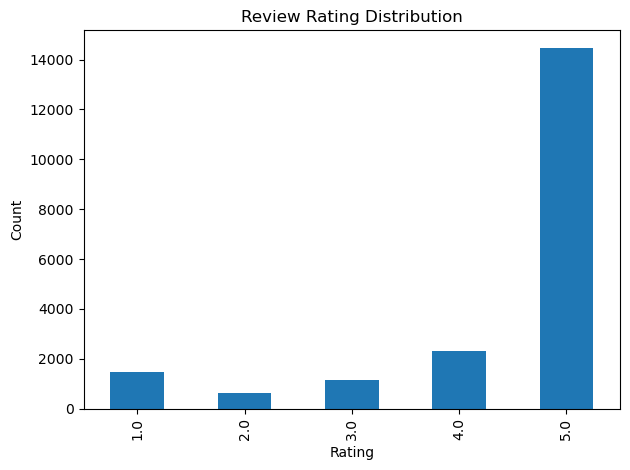

In [23]:
rating_counts.plot(kind="bar", xlabel="Rating", ylabel="Count", title="Review Rating Distribution")
plt.tight_layout()
plt.show()

## Review text length

In [24]:
reviews_df["text_len"] = reviews_df["text"].fillna("").str.len()
reviews_df["text_len"].describe()

count    20000.000000
mean       223.180000
std        388.555509
min          1.000000
25%         45.000000
50%        112.000000
75%        251.000000
max      15807.000000
Name: text_len, dtype: float64

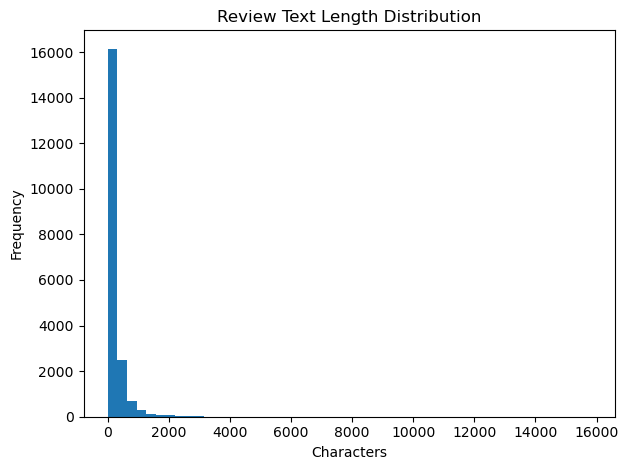

In [25]:
reviews_df["text_len"].plot(kind="hist", bins=50, title="Review Text Length Distribution", xlabel="Characters")
plt.tight_layout()
plt.show()

## Verified purchase ratio

In [26]:
reviews_df["verified_purchase"].value_counts(normalize=True)

verified_purchase
True     0.92495
False    0.07505
Name: proportion, dtype: float64

## Price distribution (metadata)

In [27]:
meta_df["price"].describe()

count    11208.000000
mean        88.494953
std        310.535168
min          0.010000
25%         14.990000
50%         26.990000
75%         59.950000
max       7691.010000
Name: price, dtype: float64

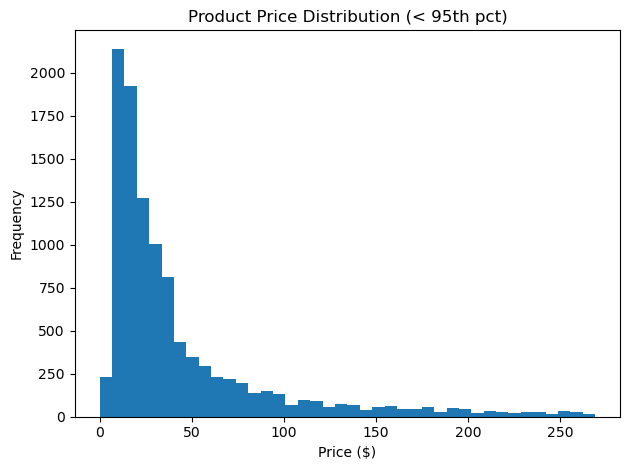

In [28]:
# drop nulls and extreme outliers for a readable plot
prices = meta_df["price"].dropna()
prices = prices[prices < prices.quantile(0.95)]
prices.plot(kind="hist", bins=40, title="Product Price Distribution (< 95th pct)", xlabel="Price ($)")
plt.tight_layout()
plt.show()

## Average product rating distribution

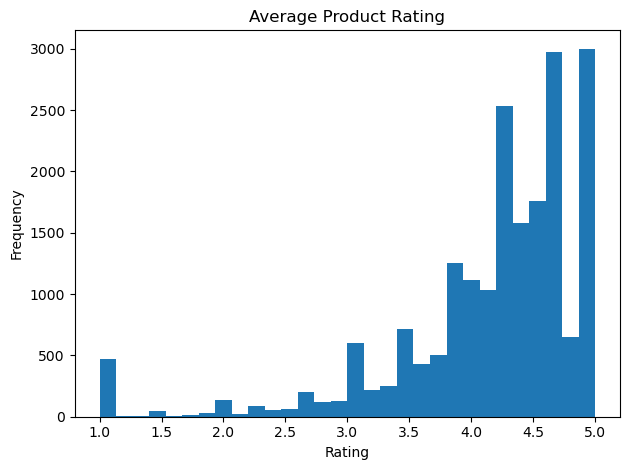

In [29]:
meta_df["average_rating"].dropna().plot(kind="hist", bins=30, title="Average Product Rating", xlabel="Rating")
plt.tight_layout()
plt.show()

## Field selection and justification

For the retrieval system we need two things: a text representation of each product (for indexing/search) and metadata for display.

**Fields used from metadata:**
- `title` -- the product name, most important for matching keyword queries
- `description` -- detailed product info, useful for semantic matching on features or use cases
- `features` -- bullet-point product specs, gives structured info about what the product does
- `price` -- for filtering and display
- `average_rating` -- for display and potential ranking signal

**Fields used from reviews:**
- `text` -- the actual review text, gives real user language about the product which helps semantic search
- `rating` -- for display
- `verified_purchase` -- trust signal
- `helpful_vote` -- can prioritize more helpful reviews

The join key is `parent_asin` which links reviews to their product.

The idea is to combine product title + description + features + review text into a single document per product (or per review) for indexing. Title and description capture what the product *is*, while review text captures how people *use and feel about* it. This combination should help both keyword (BM25) and semantic retrieval.

## Merge reviews with metadata

In [30]:
merged_parquet = str(PROCESSED_DIR / "appliances_merged.parquet")

con.execute(f"""
    COPY (
        SELECT
            r.rating,
            r.title AS review_title,
            r.text AS review_text,
            r.asin,
            r.parent_asin,
            r.helpful_vote,
            r.verified_purchase,
            m.title AS product_title,
            m.description AS product_description,
            m.features AS product_features,
            m.price,
            m.average_rating,
            m.main_category
        FROM read_parquet('{reviews_parquet}') r
        LEFT JOIN read_parquet('{meta_parquet}') m USING (parent_asin)
    )
    TO '{merged_parquet}' (FORMAT PARQUET, COMPRESSION ZSTD)
""")

print("merged")

merged


In [31]:
merged_df = pd.read_parquet(merged_parquet)
merged_df.shape

(20000, 13)

In [32]:
merged_df.head()

,rating,review_title,review_text,asin,parent_asin,helpful_vote,verified_purchase,product_title,product_description,product_features,price,average_rating,main_category
0,5.0,Just what we needed.,Just what we needed.,B07W42P978,B07W42P978,0,True,WD12X10327 Rack Roller and stud assembly Kit (...,[],[【PARTS NUMBER】The WD12X10327 dishwasher top r...,8.99,4.6,Appliances
1,5.0,Excellent Cold Brew Filter,"This filter is tall, has a very fine mesh and ...",B083Q6Y54F,B083Q6Y54F,0,True,G.a HOMEFAVOR Cold Brew Coffee Infuser 64oz (2...,[],[COMPLETE COLD BREW SYSTEM: The Cold Brew Kit ...,NaN,4.5,Amazon Home
2,1.0,Roller bearing too tight,I have installed hundreds of these rollers the...,B07TVL7F1M,B0BLZQYHPT,0,True,349241T Dryer Drum Roller Kit Whirlpool Kenmor...,[],[💡 Drum Roller 349241t - An equivalent for par...,7.95,4.3,Industrial & Scientific
3,5.0,Works well,Same as OEM product. Was easy and quick to ins...,B01AQHSNSM,B01AQHSNSM,0,True,SAMSUNG DA97-11092B Genuine OEM Ice Maker Asse...,[This high quality Genuine OEM Samsung Ice Mak...,[The Samsung DA97-11092B Ice Maker Assembly is...,138.00,4.6,Tools & Home Improvement
4,5.0,Getting very fast shipping!,Can't live without them!,B077H7V2FZ,B0BWCL9WCH,0,True,PARTY BARGAINS 600 Paper Coffee Filters - Whit...,[PARTY BARGAINS Disposable Coffee Filters | Si...,[✅ HIGH-QUALITY COFFEE FILTERS - Made of premi...,28.99,4.5,Amazon Home


In [33]:
merged_df.isnull().sum()

rating                     0
review_title               0
review_text                0
asin                       0
parent_asin                0
helpful_vote               0
verified_purchase          0
product_title          12717
product_description    12717
product_features       12717
price                  14065
average_rating         12717
main_category          12719
dtype: int64

## Preprocessing and cleanup

Decisions:
- Drop rows where `review_text` is null or empty -- we can't index a product without any text
- Drop rows where `product_title` is null -- we need at least a title to identify the product
- Keep the original text as-is for display purposes
- Tokenization and lowercasing will happen in `src/` when building the BM25 and semantic indexes, not here
- We don't remove stopwords at this stage since that's a retrieval-specific decision

In [34]:
clean_df = merged_df.dropna(subset=["review_text", "product_title"])
clean_df = clean_df[clean_df["review_text"].str.strip().str.len() > 0].copy()
clean_df.shape

(7283, 13)

In [35]:
# how many rows did we lose
merged_df.shape[0] - clean_df.shape[0]

12717

In [36]:
clean_df.isnull().sum()

rating                    0
review_title              0
review_text               0
asin                      0
parent_asin               0
helpful_vote              0
verified_purchase         0
product_title             0
product_description       0
product_features          0
price                  1348
average_rating            0
main_category             2
dtype: int64

In [37]:
# number of unique products
clean_df["parent_asin"].nunique()

2520

## Save cleaned data

In [38]:
output_path = str(PROCESSED_DIR / "appliances_clean.parquet")
clean_df.to_parquet(output_path, compression="zstd", index=False)
print(f"saved {len(clean_df)} rows to {output_path}")

saved 7283 rows to ../data/processed/appliances_clean.parquet


## Summary

- Downloaded 20K reviews and metadata for the Appliances category
- Merged on `parent_asin` to get product info alongside each review
- Dropped rows with missing review text or product title
- Final dataset ready for retrieval indexing in `data/processed/appliances_clean.parquet`